# Detailed Explanation of Project Description and Analysis Process 
This project aims to analyze the behavioral characteristics of merchants when using the subscription function, and explore the usage preferences of different payment products across countries, industries, and enterprise sizes. Through steps such as data cleaning, feature engineering, modeling, and visualization, it ultimately provides a basis for optimizing product strategies and personalized recommendations. 
---

## 🧭 Overview of the Analysis Process: 
1. **Data Cleaning**: Standardize dates, convert numerical values, handle missing values to ensure data availability.
2. **Feature Engineering**: Construct key business features (such as subscription rate, payment cycle, year-on-year growth rate, etc.).
3. **Sample Balance Handling**: To avoid model bias towards the majority class, under-sample the target variable.
4. **Machine Learning Modeling**: Use logistic regression, decision trees, and random forests for classification modeling.
5. **Model Evaluation**: Use metrics such as Accuracy, Precision, Recall, and F1 to evaluate performance.
6. **Model Parameter Tuning**: Use GridSearchCV to optimize hyperparameters to improve generalization ability.
7. **Enhanced Feature Engineering**: Incorporate sample size and subscription ratio based on country, industry, and enterprise size.
8. **Visualization Analysis**: Use a bar chart of "percentage × merchant quantity" to display payment product usage preferences. 


In [1]:
import pandas as pd
import numpy as np
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from imblearn.under_sampling import RandomUnderSampler

In [2]:
merchants_df = pd.read_excel("dstakehome_merchants.xlsx")
payments_df = pd.read_excel("dstakehome_payments.xlsx")



In [3]:
merchants_df["first_charge_date"] = pd.to_datetime(merchants_df["first_charge_date"], errors='coerce')
payments_df["date"] = pd.to_datetime(payments_df["date"], errors='coerce')


In [4]:
print("Merchants ：", merchants_df["first_charge_date"].isna().sum())
print("Payments ：", payments_df["date"].isna().sum())

print(merchants_df[merchants_df["first_charge_date"].isna()])
print(payments_df[payments_df["date"].isna()])

Merchants ： 26
Payments ： 0
       merchant                                           industry  \
886    b52415cd  Medical services, drugs, testing labs & equipm...   
993    42c99742                                           Software   
5190   c9f201c3                                          Education   
5527   b48d72d6             Religion, politics & other memberships   
7891   0feb8833                                             Others   
14536  9a872ef8                                  Art & photography   
15418  b46439ab                                             Others   
16059  9297a93e                                            Leisure   
17808  09161a36                                  Personal services   
18555  e8e90972                                  Personal services   
18693  0eef803b                                      Digital goods   
19400  3e09d6fe                                  Business services   
20109  877ea59a                              Grocery & food st

In [5]:
merchants_df = merchants_df.dropna(subset=["first_charge_date"])
payments_df = payments_df.dropna(subset=["date"])


In [6]:
numeric_columns = ["subscription_volume", "checkout_volume", "payment_link_volume", "total_volume"]

payments_df[numeric_columns] = payments_df[numeric_columns].apply(pd.to_numeric, errors="coerce")

payments_df[numeric_columns] = payments_df[numeric_columns].fillna(0)

In [7]:
payments_df["merchant"] = payments_df["merchant"].astype(str)
merchants_df["merchant"] = merchants_df["merchant"].astype(str)


In [9]:
print("Data types of the columns in the payment data:")
print(payments_df.dtypes)

print("\nData types of the columns in the merchant data:")
print(merchants_df.dtypes)

print("\nStatistics of NaN values in payment data:")
print(payments_df.isna().sum())

print("\nStatistics of NaN values in merchant data:")
print(merchants_df.isna().sum())


Data types of the columns in the payment data:
date                   datetime64[ns, UTC]
merchant                            object
subscription_volume                  int64
checkout_volume                      int64
payment_link_volume                  int64
total_volume                         int64
dtype: object

Data types of the columns in the merchant data:
merchant                          object
industry                          object
first_charge_date    datetime64[ns, UTC]
country                           object
business_size                     object
dtype: object

Statistics of NaN values in payment data:
date                   0
merchant               0
subscription_volume    0
checkout_volume        0
payment_link_volume    0
total_volume           0
dtype: int64

Statistics of NaN values in merchant data:
merchant             0
industry             0
first_charge_date    0
country              0
business_size        0
dtype: int64


In [11]:
print("\nMissing values in payment data:")
print(merchants_df.isnull().sum())

print("\nMissing values in merchant data:")
print(payments_df.isnull().sum())

print("\nStatistical information of the merchant data:")
print(merchants_df.describe())

print("\nStatistical information of the payment data:")
print(payments_df.describe())



Missing values in payment data:
merchant             0
industry             0
first_charge_date    0
country              0
business_size        0
dtype: int64

Missing values in merchant data:
date                   0
merchant               0
subscription_volume    0
checkout_volume        0
payment_link_volume    0
total_volume           0
dtype: int64

Statistical information of the merchant data:
       merchant           industry                    first_charge_date  \
count     23601              23601                                23601   
unique    23594                 30                                  NaN   
top           0  Business services                                  NaN   
freq          8               3141                                  NaN   
mean        NaN                NaN  2040-05-06 03:24:34.869708800+00:00   
min         NaN                NaN            2030-11-07 00:00:00+00:00   
25%         NaN                NaN            2039-06-25 00:00:00+00:0

Analysis 


In [12]:
industry_summary = payments_df.merge(merchants_df, on="merchant", how="left").groupby("industry")[["subscription_volume", "checkout_volume", "payment_link_volume"]].sum()
industry_summary["most_used_product"] = industry_summary.idxmax(axis=1)
print(industry_summary)



                                                    subscription_volume  \
industry                                                                  
0                                                                     0   
Art & photography                                              34646416   
Automotive parts and repair/service shops                     118546872   
Business services                                            5316338367   
Charity                                                       851604847   
Clothing & accessory                                          129773970   
Construction                                                  226168356   
Consulting services                                           155413304   
Cosmetics                                                       9915307   
Digital goods                                                3067387929   
Education                                                    2519657574   
Electronics              

In [13]:
business_size_summary = payments_df.merge(merchants_df, on="merchant", how="left").groupby("business_size")[["subscription_volume", "checkout_volume", "payment_link_volume"]].sum()
business_size_summary["most_used_product"] = business_size_summary.idxmax(axis=1)
print(business_size_summary)



               subscription_volume  checkout_volume  payment_link_volume  \
business_size                                                              
large                   1129889559        152747668             27141506   
medium                 29716626432       2599019835            133129466   
small                  31079584470      14627587613           2743040229   

                 most_used_product  
business_size                       
large          subscription_volume  
medium         subscription_volume  
small          subscription_volume  


In [14]:
country_summary = payments_df.merge(merchants_df, on="merchant", how="left").groupby("country")[["subscription_volume", "checkout_volume", "payment_link_volume"]].sum()
country_summary["most_used_product"] = country_summary.idxmax(axis=1)
print(country_summary)

         subscription_volume  checkout_volume  payment_link_volume  \
country                                                              
AE                 120168880        139723333            168732838   
AT                  14647760        190341977              7672818   
AU                1466968800        365807259             71637230   
BE                 215454743         53588787              5737152   
BG                   2389489         49571422              1447672   
BR                  40404668        218315224             45207680   
CA                1220619742        888001366            159929958   
CH                  71112832        154757036              3430599   
CY                   1126144         28273674              6737753   
CZ                   1884564         21333080              4318545   
DE                 181392244        205086317             15929666   
DK                 587785218         68944813              2506942   
EE                 1

In [15]:
all_products_merchants = payments_df.groupby("merchant")[["subscription_volume", "checkout_volume", "payment_link_volume"]].apply(lambda x: (x > 0).sum(axis=1).max())
all_products_count = all_products_merchants[all_products_merchants == 3].count()
print(f"\n{all_products_count}")


78


In [17]:

business_size_summary = payments_df.merge(merchants_df, on="merchant", how="left").groupby("business_size")[["subscription_volume", "checkout_volume", "payment_link_volume"]].sum()

industry_summary = payments_df.merge(merchants_df, on="merchant", how="left").groupby("industry")[["subscription_volume", "checkout_volume", "payment_link_volume"]].sum()

country_summary = payments_df.merge(merchants_df, on="merchant", how="left").groupby("country")[["subscription_volume", "checkout_volume", "payment_link_volume"]].sum()

business_size_summary = business_size_summary.div(business_size_summary.sum(axis=1), axis=0)
industry_summary = industry_summary.div(industry_summary.sum(axis=1), axis=0)
country_summary = country_summary.div(country_summary.sum(axis=1), axis=0)



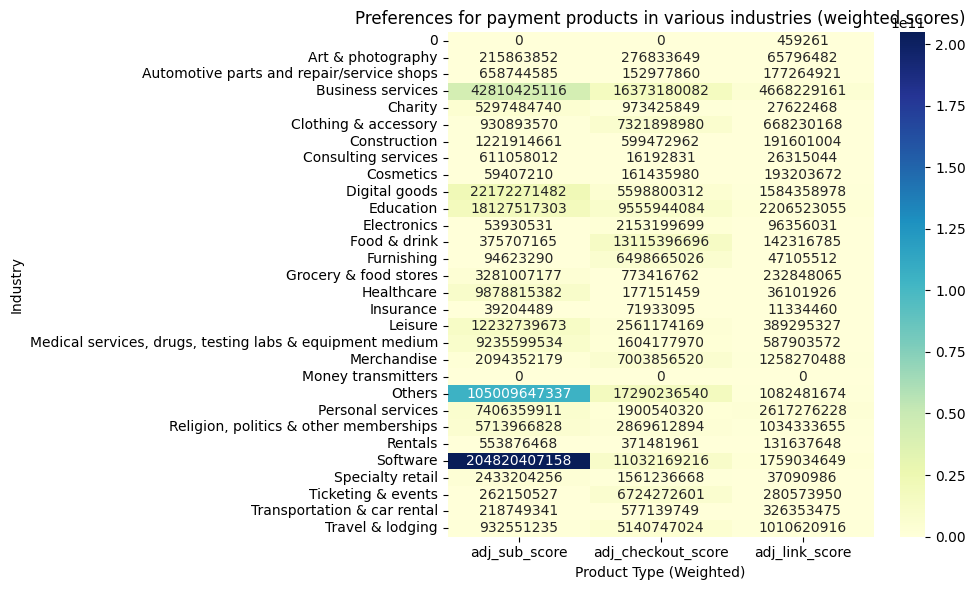

/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/2949282837.py:47: UserWarning: Glyph 21152 (\N{CJK UNIFIED IDEOGRAPH-52A0}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/2949282837.py:47: UserWarning: Glyph 26435 (\N{CJK UNIFIED IDEOGRAPH-6743}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/2949282837.py:47: UserWarning: Glyph 20132 (\N{CJK UNIFIED IDEOGRAPH-4EA4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/2949282837.py:47: UserWarning: Glyph 26131 (\N{CJK UNIFIED IDEOGRAPH-6613}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/2949282837.py:47: UserWarning: Glyph 35780 (\N{CJK UNIFIED IDEOGRAPH-8BC4}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/k5/t9j0

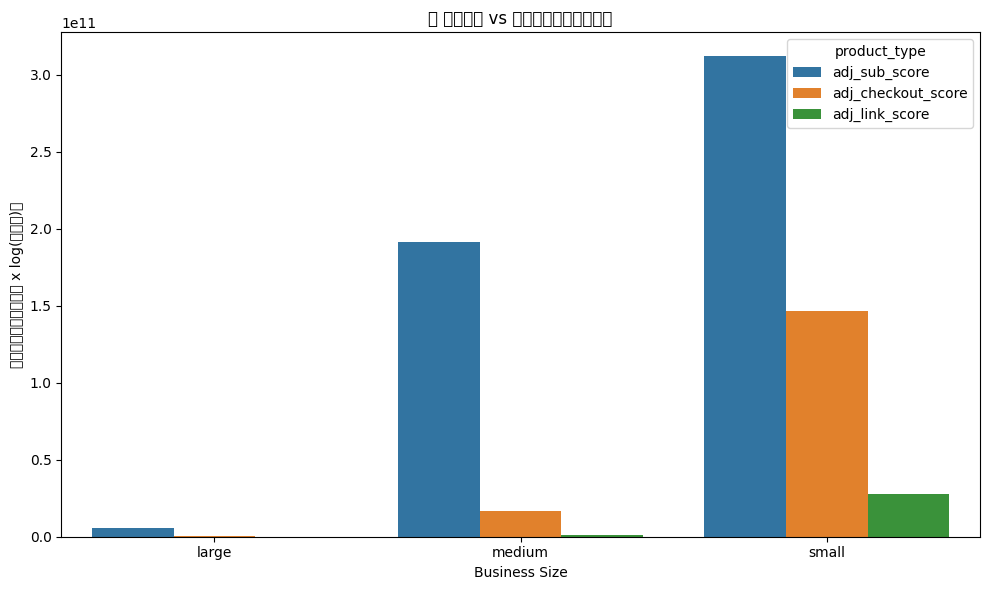

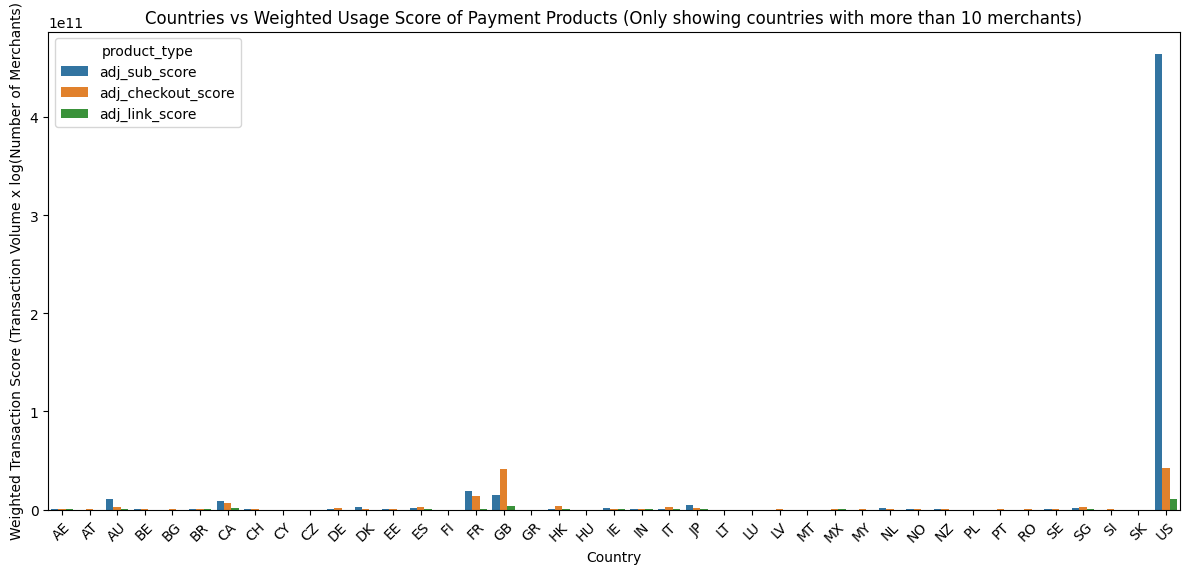

In [18]:


summary_df = payments_df.merge(merchants_df, on="merchant", how="left")

industry_group = summary_df.groupby("industry").agg(
    subscription_volume_sum=("subscription_volume", "sum"),
    checkout_volume_sum=("checkout_volume", "sum"),
    payment_link_volume_sum=("payment_link_volume", "sum"),
    merchant_count=("merchant", "nunique")
).reset_index()

industry_total_volume = industry_group[["subscription_volume_sum", "checkout_volume_sum", "payment_link_volume_sum"]].sum(axis=1)
industry_group["sub_ratio"] = industry_group["subscription_volume_sum"] / industry_total_volume
industry_group["checkout_ratio"] = industry_group["checkout_volume_sum"] / industry_total_volume
industry_group["link_ratio"] = industry_group["payment_link_volume_sum"] / industry_total_volume

industry_group["adj_sub_score"] = industry_group["subscription_volume_sum"] * np.log1p(industry_group["merchant_count"])
industry_group["adj_checkout_score"] = industry_group["checkout_volume_sum"] * np.log1p(industry_group["merchant_count"])
industry_group["adj_link_score"] = industry_group["payment_link_volume_sum"] * np.log1p(industry_group["merchant_count"])

industry_heatmap = industry_group[["industry", "adj_sub_score", "adj_checkout_score", "adj_link_score"]].set_index("industry")
plt.figure(figsize=(10, 6))
sns.heatmap(industry_heatmap, annot=True, fmt=".0f", cmap="YlGnBu")
plt.title("Preferences for payment products in various industries (weighted scores)")
plt.ylabel("Industry")
plt.xlabel("Product Type (Weighted)")
plt.tight_layout()
plt.show()


size_group = summary_df.groupby("business_size").agg(
    subscription_volume_sum=("subscription_volume", "sum"),
    checkout_volume_sum=("checkout_volume", "sum"),
    payment_link_volume_sum=("payment_link_volume", "sum"),
    merchant_count=("merchant", "nunique")
).reset_index()

size_group["adj_sub_score"] = size_group["subscription_volume_sum"] * np.log1p(size_group["merchant_count"])
size_group["adj_checkout_score"] = size_group["checkout_volume_sum"] * np.log1p(size_group["merchant_count"])
size_group["adj_link_score"] = size_group["payment_link_volume_sum"] * np.log1p(size_group["merchant_count"])

size_melted = size_group.melt(id_vars=["business_size"], value_vars=["adj_sub_score", "adj_checkout_score", "adj_link_score"],
                              var_name="product_type", value_name="adjusted_score")
plt.figure(figsize=(10, 6))
sns.barplot(data=size_melted, x="business_size", y="adjusted_score", hue="product_type")
plt.title("Business Size vs. Weighted Payment Product Usage Score")
plt.ylabel("Weighted Transaction Score (Transaction Volume × log(Number of Merchants))")
plt.xlabel("Business Size")
plt.tight_layout()
plt.show()


country_group = summary_df.groupby("country").agg(
    subscription_volume_sum=("subscription_volume", "sum"),
    checkout_volume_sum=("checkout_volume", "sum"),
    payment_link_volume_sum=("payment_link_volume", "sum"),
    merchant_count=("merchant", "nunique")
).reset_index()

country_group["adj_sub_score"] = country_group["subscription_volume_sum"] * np.log1p(country_group["merchant_count"])
country_group["adj_checkout_score"] = country_group["checkout_volume_sum"] * np.log1p(country_group["merchant_count"])
country_group["adj_link_score"] = country_group["payment_link_volume_sum"] * np.log1p(country_group["merchant_count"])

top_country = country_group[country_group["merchant_count"] > 10]

country_melted = top_country.melt(id_vars=["country"], value_vars=["adj_sub_score", "adj_checkout_score", "adj_link_score"],
                                  var_name="product_type", value_name="adjusted_score")
plt.figure(figsize=(12, 6))
sns.barplot(data=country_melted, x="country", y="adjusted_score", hue="product_type")
plt.title("Countries vs Weighted Usage Score of Payment Products (Only showing countries with more than 10 merchants)")
plt.ylabel("Weighted Transaction Score (Transaction Volume x log(Number of Merchants)")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



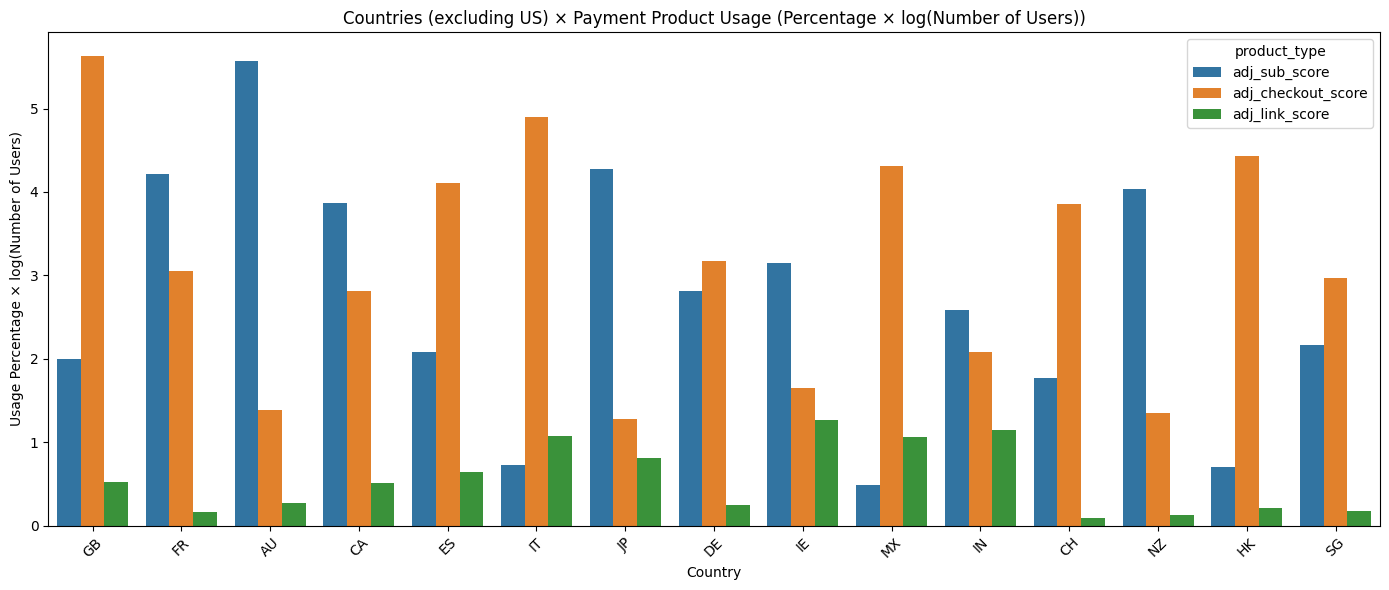

In [19]:

country_df = payments_df.merge(merchants_df, on="merchant", how="left")
country_summary = country_df[country_df["country"] != "US"].groupby("country").agg(
    total_subscription=("subscription_volume", "sum"),
    total_checkout=("checkout_volume", "sum"),
    total_payment_link=("payment_link_volume", "sum"),
    num_merchants=("merchant", "nunique")
).reset_index()

country_summary["sum_volume"] = country_summary[["total_subscription", "total_checkout", "total_payment_link"]].sum(axis=1)
country_summary["adj_sub_score"] = country_summary["total_subscription"] / country_summary["sum_volume"] * np.log1p(country_summary["num_merchants"])
country_summary["adj_checkout_score"] = country_summary["total_checkout"] / country_summary["sum_volume"] * np.log1p(country_summary["num_merchants"])
country_summary["adj_link_score"] = country_summary["total_payment_link"] / country_summary["sum_volume"] * np.log1p(country_summary["num_merchants"])

melted = country_summary.sort_values("num_merchants", ascending=False).head(15).melt(id_vars=["country"], value_vars=["adj_sub_score", "adj_checkout_score", "adj_link_score"], var_name="product_type", value_name="adjusted_score")

plt.figure(figsize=(14,6))
sns.barplot(data=melted, x="country", y="adjusted_score", hue="product_type")
plt.title("Countries (excluding US) × Payment Product Usage (Percentage × log(Number of Users))")
plt.ylabel("Usage Percentage × log(Number of Users)")
plt.xlabel("Country")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

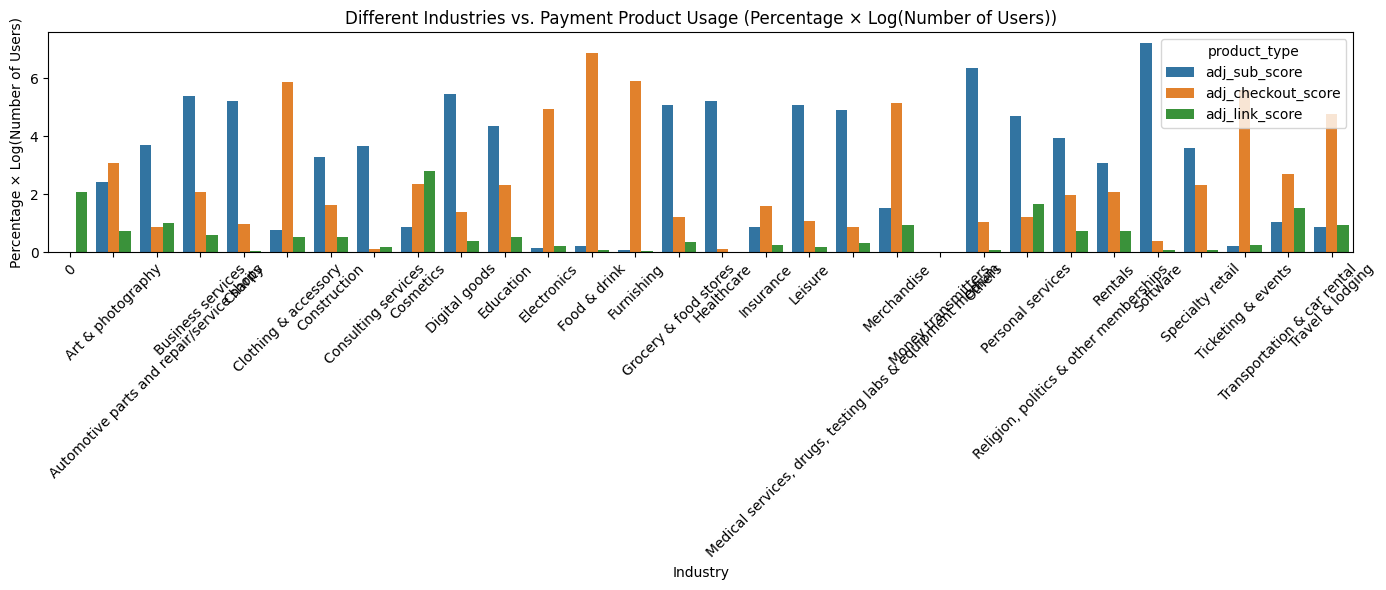

In [20]:


industry_df = payments_df.merge(merchants_df, on="merchant", how="left")
industry_summary = industry_df.groupby("industry").agg(
    total_subscription=("subscription_volume", "sum"),
    total_checkout=("checkout_volume", "sum"),
    total_payment_link=("payment_link_volume", "sum"),
    num_merchants=("merchant", "nunique")
).reset_index()

industry_summary["sum_volume"] = industry_summary[["total_subscription", "total_checkout", "total_payment_link"]].sum(axis=1)
industry_summary["adj_sub_score"] = industry_summary["total_subscription"] / industry_summary["sum_volume"] * np.log1p(industry_summary["num_merchants"])
industry_summary["adj_checkout_score"] = industry_summary["total_checkout"] / industry_summary["sum_volume"] * np.log1p(industry_summary["num_merchants"])
industry_summary["adj_link_score"] = industry_summary["total_payment_link"] / industry_summary["sum_volume"] * np.log1p(industry_summary["num_merchants"])

melted = industry_summary.melt(id_vars=["industry"], value_vars=["adj_sub_score", "adj_checkout_score", "adj_link_score"], var_name="product_type", value_name="adjusted_score")
plt.figure(figsize=(14,6))
sns.barplot(data=melted, x="industry", y="adjusted_score", hue="product_type")
plt.title("Different Industries vs. Payment Product Usage (Percentage × Log(Number of Users))")
plt.ylabel("Percentage × Log(Number of Users)")
plt.xlabel("Industry")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:

merchant_payments = payments_df.groupby("merchant").agg(
    subscription_volume=("subscription_volume", "sum"),  
    total_volume=("total_volume", "sum"),  
    first_transaction=("date", "min"), 
    last_transaction=("date", "max"),  
    transaction_count=("date", "count")  
).reset_index()

merchant_payments["used_subscription"] = (merchant_payments["subscription_volume"] > 0).astype(int)

print(merchant_payments["used_subscription"].value_counts())



used_subscription
0    19209
1     4411
Name: count, dtype: int64


In [22]:
# transaction_duration_days
merchant_payments["transaction_duration_days"] = (merchant_payments["last_transaction"] - merchant_payments["first_transaction"]).dt.days


In [23]:
# subscription_rate
merchant_payments["subscription_rate"] = merchant_payments["subscription_volume"] / merchant_payments["total_volume"]

merchant_payments["subscription_rate"] = merchant_payments["subscription_rate"].fillna(0)


In [24]:

payments_df["year_month"] = payments_df["date"].dt.to_period("M")
monthly_transactions = payments_df.groupby(["merchant", "year_month"])["total_volume"].count().reset_index(name="monthly_count")
avg_monthly_tx = monthly_transactions.groupby("merchant")["monthly_count"].mean().reset_index(name="avg_monthly_payments")

merchant_payments = merchant_payments.merge(avg_monthly_tx, on="merchant", how="left")
merchant_payments["avg_monthly_payments"] = merchant_payments["avg_monthly_payments"].fillna(0)

/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/32384477.py:1: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  payments_df["year_month"] = payments_df["date"].dt.to_period("M")


In [25]:
payments_df["week"] = payments_df["date"].dt.strftime("%Y-%W")

weekly_growth = payments_df.groupby(["merchant", "week"])["total_volume"].sum().unstack().pct_change(axis=1)

weekly_growth_mean = weekly_growth.mean(axis=1).reset_index().rename(columns={0: "week_over_week_rate"})

merchant_payments = merchant_payments.merge(weekly_growth_mean, on="merchant", how="left")

merchant_payments["week_over_week_rate"] = merchant_payments["week_over_week_rate"].fillna(0)


/var/folders/k5/t9j09j4s5lbfwsk43_nfn_qh0000gn/T/ipykernel_35869/428288952.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  weekly_growth = payments_df.groupby(["merchant", "week"])["total_volume"].sum().unstack().pct_change(axis=1)


In [26]:
# payment_cycle
payments_df["day_of_month"] = payments_df["date"].dt.day

payment_cycle = payments_df.groupby("merchant")["day_of_month"].agg(lambda x: x.mode()[0] if len(x.mode()) > 0 else np.nan).reset_index()

payment_cycle.rename(columns={"day_of_month": "payment_cycle_day"}, inplace=True)

# merge `payment_cycle_day` to `merchant_payments`
merchant_payments = merchant_payments.merge(payment_cycle, on="merchant", how="left")


In [27]:
merchant_features = merchants_df[["merchant", "industry", "country", "business_size"]]

# merge `merchant_payments`
merchant_payments = merchant_payments.merge(merchant_features, on="merchant", how="left")

# One-Hot code
merchant_payments = pd.get_dummies(merchant_payments, columns=["industry", "country", "business_size"], drop_first=True)


In [28]:

for col in merchant_payments.select_dtypes(include=["datetime64[ns, UTC]", "datetime64[ns]"]).columns:
    merchant_payments[col] = merchant_payments[col].dt.tz_localize(None)

output_file_path = "merchant_payments_with_features.xlsx"
merchant_payments.to_excel(output_file_path, index=False)

print(f" {output_file_path}")



 merchant_payments_with_features.xlsx


In [29]:
pd.set_option('display.max_columns', None)
merchant_payments.head()


,merchant,subscription_volume,total_volume,first_transaction,last_transaction,transaction_count,used_subscription,transaction_duration_days,subscription_rate,avg_monthly_payments,week_over_week_rate,payment_cycle_day,industry_Art & photography,industry_Automotive parts and repair/service shops,industry_Business services,industry_Charity,industry_Clothing & accessory,industry_Construction,industry_Consulting services,industry_Cosmetics,industry_Digital goods,industry_Education,industry_Electronics,industry_Food & drink,industry_Furnishing,industry_Grocery & food stores,industry_Healthcare,industry_Insurance,industry_Leisure,"industry_Medical services, drugs, testing labs & equipment medium",industry_Merchandise,industry_Money transmitters,industry_Others,industry_Personal services,"industry_Religion, politics & other memberships",industry_Rentals,industry_Software,industry_Specialty retail,industry_Ticketing & events,industry_Transportation & car rental,industry_Travel & lodging,country_AT,country_AU,country_BE,country_BG,country_BR,country_CA,country_CH,country_CY,country_CZ,country_DE,country_DK,country_EE,country_ES,country_FI,country_FR,country_GB,country_GI,country_GR,country_HK,country_HR,country_HU,country_IE,country_IN,country_IT,country_JP,country_LT,country_LU,country_LV,country_MT,country_MX,country_MY,country_NL,country_NO,country_NZ,country_PL,country_PT,country_RO,country_SE,country_SG,country_SI,country_SK,country_TH,country_US,business_size_medium,business_size_small
0,0,11832,2810840,2041-06-11,2042-06-22,150,1,376,0.004209,11.538462,3.924812,15,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True
1,0,11832,2810840,2041-06-11,2042-06-22,150,1,376,0.004209,11.538462,3.924812,15,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
2,0,11832,2810840,2041-06-11,2042-06-22,150,1,376,0.004209,11.538462,3.924812,15,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
3,0,11832,2810840,2041-06-11,2042-06-22,150,1,376,0.004209,11.538462,3.924812,15,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True
4,0,11832,2810840,2041-06-11,2042-06-22,150,1,376,0.004209,11.538462,3.924812,15,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,F

In [30]:
merchant_payments.describe()

,subscription_volume,total_volume,first_transaction,last_transaction,transaction_count,used_subscription,transaction_duration_days,subscription_rate,avg_monthly_payments,week_over_week_rate,payment_cycle_day
count,2.362700e+04,2.362700e+04,23627,23627,23627.000000,23627.000000,23627.000000,23627.000000,23627.000000,23627.000000,23627.000000
mean,2.621089e+06,2.392868e+07,2041-08-22 10:40:40.631481088,2042-03-25 23:09:35.798874368,66.827655,0.186989,215.520083,0.129199,6.340399,4.060522,10.166716
min,0.000000e+00,1.000000e+00,2041-05-01 00:00:00,2041-05-01 00:00:00,1.000000,0.000000,0.000000,0.000000,1.000000,-0.810134,1.000000
25%,0.000000e+00,2.895150e+04,2041-05-04 00:00:00,2042-01-26 00:00:00,3.000000,0.000000,34.000000,0.000000,1.000000,0.000000,3.000000
50%,0.000000e+00,2.565600e+05,2041-06-20 00:00:00,2042-05-31 00:00:00,14.000000,0.000000,224.000000,0.000000,2.444444,0.146936,8.000000
75%,0.000000e+00,1.953697e+06,2041-11-24 00:00:00,2042-06-20 00:00:00,73.000000,0.000000,396.000000,0.000000,8.000000,0.640702,16.000000
max,9.823618e+09,9.892636e+10,2042-06-22 00:00:00,2042-06-22 00:00:00,418.000000,1.000000,417.000000,1.000000,30.454545,4719.989731,31.000000
std,9.512406e+07,8.217755e+08,NaN,NaN,108.680016,0.389911,165.331598,0.312576,7.922626,58.390487,8.197455


In [31]:
num_features = ["subscription_volume", "total_volume", "transaction_duration_days", "subscription_rate", "week_over_week_rate"]

scaler = StandardScaler()
merchant_payments[num_features] = scaler.fit_transform(merchant_payments[num_features])


Models


In [32]:
# machine learning
X = merchant_payments.drop(columns=["merchant", "used_subscription"])
y = merchant_payments["used_subscription"]

undersampler = RandomUnderSampler(random_state=42)
X_resampled, y_resampled = undersampler.fit_resample(X, y)

print(merchant_payments["used_subscription"].value_counts())

print(pd.Series(y_resampled).value_counts())


used_subscription
0    19209
1     4418
Name: count, dtype: int64
used_subscription
0    4418
1    4418
Name: count, dtype: int64


In [33]:
if "first_transaction" in X_resampled.columns:
    X_resampled["first_transaction"] = pd.to_datetime(X_resampled["first_transaction"], errors="coerce").dt.tz_localize(None)

if "last_transaction" in X_resampled.columns:
    X_resampled["last_transaction"] = pd.to_datetime(X_resampled["last_transaction"], errors="coerce").dt.tz_localize(None)

if "first_transaction" in X_resampled.columns:
    X_resampled["first_transaction"] = (X_resampled["first_transaction"] - pd.Timestamp("1970-01-01")) // pd.Timedelta("1D")

if "last_transaction" in X_resampled.columns:
    X_resampled["last_transaction"] = (X_resampled["last_transaction"] - pd.Timestamp("1970-01-01")) // pd.Timedelta("1D")

if "transaction_duration_days" in X_resampled.columns:
    X_resampled["transaction_duration_days"] = X_resampled["transaction_duration_days"].astype(int)

print(X_resampled.dtypes)


subscription_volume     float64
total_volume            float64
first_transaction         int64
last_transaction          int64
transaction_count         int64
                         ...   
country_SK                 bool
country_TH                 bool
country_US                 bool
business_size_medium       bool
business_size_small        bool
Length: 84, dtype: object


In [39]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)


# train RandomForest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)


# evaluate 
rf_preds = rf_model.predict(X_test)

print(f" RandomForest Accuracy: {accuracy_score(y_test, rf_preds):.4f}")

print("\n RandomForest Classification Report:")
print(classification_report(y_test, rf_preds))






 RandomForest Accuracy: 0.9994

 RandomForest Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       884
           1       1.00      1.00      1.00       884

    accuracy                           1.00      1768
   macro avg       1.00      1.00      1.00      1768
weighted avg       1.00      1.00      1.00      1768



In [35]:

from sklearn.linear_model import LogisticRegression

# train Logistic Regression 
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# evaluate model
log_preds = log_model.predict(X_test)

print(f" Logistic Regression Accuracy: {accuracy_score(y_test, log_preds):.4f}")

print("\n Logistic Regression Classification Report:")
print(classification_report(y_test, log_preds))


 Logistic Regression Accuracy: 0.9655

 Logistic Regression Classification Report:
              precision    recall  f1-score   support

           0       0.94      1.00      0.97       884
           1       1.00      0.93      0.96       884

    accuracy                           0.97      1768
   macro avg       0.97      0.97      0.97      1768
weighted avg       0.97      0.97      0.97      1768



/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



## 
set up separate parameter search spaces for each model (logistic regression, decision tree, random forest), avoiding a one-size-fits-all approach and specifically controlling the depth of the decision tree to prevent overfitting. We will also output the performance comparison between the training set and the test set to check if the model exhibits overfitting.


In [36]:

from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

param_grids = {
    "Logistic Regression": {
        "model": LogisticRegression(max_iter=1000, random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10]
        }
    },
    "Decision Tree": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "max_depth": [3, 5, 10],  
            "min_samples_split": [2, 5, 10]
        }
    },
    "Random Forest": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200],
            "max_depth": [5, 10, None]
        }
    }
}

for name, config in param_grids.items():
    print(f"{name}")
    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    print(f": {grid.best_params_}")

    # evaluate
    for dataset_name, X_eval, y_eval in [("train", X_train, y_train), ("test", X_test, y_test)]:
        y_pred = best_model.predict(X_eval)
        acc = accuracy_score(y_eval, y_pred)
        prec = precision_score(y_eval, y_pred)
        rec = recall_score(y_eval, y_pred)
        f1 = f1_score(y_eval, y_pred)
        print(f" [{dataset_name}] {name} performance：")
        print(f"  Accuracy: {acc:.4f}")
        print(f"  Precision: {prec:.4f}")
        print(f"  Recall: {rec:.4f}")
        print(f"  F1 Score: {f1:.4f}")
        print("-" * 40)


Logistic Regression


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

: {'C': 10}
 [train] Logistic Regression performance：
  Accuracy: 0.9741
  Precision: 0.9988
  Recall: 0.9493
  F1 Score: 0.9735
----------------------------------------
 [test] Logistic Regression performance：
  Accuracy: 0.9768
  Precision: 0.9988
  Recall: 0.9548
  F1 Score: 0.9763
----------------------------------------
Decision Tree
: {'max_depth': 3, 'min_samples_split': 2}
 [train] Decision Tree performance：
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
----------------------------------------
 [test] Decision Tree performance：
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
----------------------------------------
Random Forest
: {'max_depth': 5, 'n_estimators': 100}
 [train] Random Forest performance：
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
----------------------------------------
 [test] Random Forest performance：
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.00

In [37]:

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

# train Decision Tree 
dt_model = DecisionTreeClassifier(random_state=42)
dt_model.fit(X_train, y_train)

# evaluate 
models = {
    "Logistic Regression": log_model,
    "Decision Tree": dt_model,
    "Random Forest": rf_model
}

for name, model in models.items():
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    print(f" {name}")
    print(f"  Accuracy: {acc:.4f}")
    print(f"  Precision: {prec:.4f}")
    print(f"  Recall: {rec:.4f}")
    print(f"  F1 Score: {f1:.4f}")
    print("-" * 40)


 Logistic Regression
  Accuracy: 0.9655
  Precision: 1.0000
  Recall: 0.9310
  F1 Score: 0.9643
----------------------------------------
 Decision Tree
  Accuracy: 1.0000
  Precision: 1.0000
  Recall: 1.0000
  F1 Score: 1.0000
----------------------------------------
 Random Forest
  Accuracy: 0.9994
  Precision: 1.0000
  Recall: 0.9989
  F1 Score: 0.9994
----------------------------------------


In [38]:

import pandas as pd

# GridSearchCV 
results = []

for name, config in param_grids.items():
    grid = GridSearchCV(config["model"], config["params"], cv=5, scoring="f1", n_jobs=-1)
    grid.fit(X_train, y_train)
    best_model = grid.best_estimator_

    for dataset, X_eval, y_eval in [("Train", X_train, y_train), ("Test", X_test, y_test)]:
        y_pred = best_model.predict(X_eval)
        results.append({
            "Model": name,
            "Dataset": dataset,
            "Accuracy": accuracy_score(y_eval, y_pred),
            "Precision": precision_score(y_eval, y_pred),
            "Recall": recall_score(y_eval, y_pred),
            "F1 Score": f1_score(y_eval, y_pred)
        })

results_df = pd.DataFrame(results)
display(results_df.round(4))


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://sciki

,Model,Dataset,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,Train,0.9741,0.9988,0.9493,0.9735
1,Logistic Regression,Test,0.9768,0.9988,0.9548,0.9763
2,Decision Tree,Train,1.0000,1.0000,1.0000,1.0000
3,Decision Tree,Test,1.0000,1.0000,1.0000,1.0000
4,Random Forest,Train,1.0000,1.0000,1.0000,1.0000
5,Random Forest,Test,1.0000,1.0000,1.0000,1.0000
